# 09 - SMC Backtest
Walk-forward backtest combining H4 bias + M15 zones + M5 entry + Risk Management

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
load_dotenv()
import MetaTrader5 as mt5

mt5.initialize()
login = int(os.getenv('MT5_LOGIN', '0'))
password = os.getenv('MT5_PASSWORD')
server = os.getenv('MT5_SERVER', '').strip()
mt5.login(login, password=password, server=server)
print('Connected')

Connected


## 1. Load Data

In [9]:
h4 = pd.DataFrame(mt5.copy_rates_from_pos('EURUSD', mt5.TIMEFRAME_H4, 0, 2500))
m15 = pd.DataFrame(mt5.copy_rates_from_pos('EURUSD', mt5.TIMEFRAME_M15, 0, 10000))
m5 = pd.DataFrame(mt5.copy_rates_from_pos('EURUSD', mt5.TIMEFRAME_M5, 0, 20000))
mt5.shutdown()

for df in [h4, m15, m5]:
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)

print(f'H4:  {len(h4)} bars ({h4.index[0]} → {h4.index[-1]})')
print(f'M15: {len(m15)} bars ({m15.index[0]} → {m15.index[-1]})')
print(f'M5:  {len(m5)} bars ({m5.index[0]} → {m5.index[-1]})')

H4:  2500 bars (2024-10-21 00:00:00 → 2026-06-01 12:00:00)
M15: 10000 bars (2026-01-06 11:45:00 → 2026-06-01 15:30:00)
M5:  20000 bars (2026-02-24 04:35:00 → 2026-06-01 15:30:00)


## 2. SMC Detection Functions (no lookahead)

In [10]:
def find_swings(df):
    highs, lows = [], []
    for i in range(2, len(df) - 2):
        if df['high'].iloc[i] == df['high'].iloc[i-2:i+3].max():
            highs.append({'t': df.index[i], 'p': df['high'].iloc[i]})
        if df['low'].iloc[i] == df['low'].iloc[i-2:i+3].min():
            lows.append({'t': df.index[i], 'p': df['low'].iloc[i]})
    return pd.DataFrame(highs) if highs else pd.DataFrame(), pd.DataFrame(lows) if lows else pd.DataFrame()

def get_h4_bias(df):
    if len(df) < 10:
        return 'neutral'
    highs, lows = find_swings(df)
    if len(highs) < 2 or len(lows) < 2:
        return 'neutral'
    close = df['close'].iloc[-1]
    prev_high = highs['p'].iloc[-2]
    prev_low = lows['p'].iloc[-2]
    if close > prev_high:
        return 'bullish'
    if close < prev_low:
        return 'bearish'
    return 'neutral'

def find_zones(df, min_gap=0.00005, impulse_min=0.0010):
    fvgs, obs = [], []
    for i in range(2, len(df)):
        c1, c2, c3 = df.iloc[i-2], df.iloc[i-1], df.iloc[i]
        if c3['low'] > c1['high']:
            fvgs.append({'t': df.index[i], 'd': 'bullish', 'top': c3['low'], 'bot': c1['high'], 'mid': (c3['low']+c1['high'])/2})
        if c3['high'] < c1['low']:
            fvgs.append({'t': df.index[i], 'd': 'bearish', 'top': c1['low'], 'bot': c3['high'], 'mid': (c1['low']+c3['high'])/2})
    for i in range(1, len(df)):
        prev, curr = df.iloc[i-1], df.iloc[i]
        if prev['close'] < prev['open'] and curr['close']-curr['open'] >= impulse_min:
            obs.append({'t': df.index[i], 'd': 'bullish', 'top': max(prev['open'],prev['close']), 'bot': min(prev['open'],prev['close']), 'mid': (max(prev['open'],prev['close'])+min(prev['open'],prev['close']))/2})
        if prev['close'] > prev['open'] and curr['open']-curr['close'] >= impulse_min:
            obs.append({'t': df.index[i], 'd': 'bearish', 'top': max(prev['open'],prev['close']), 'bot': min(prev['open'],prev['close']), 'mid': (max(prev['open'],prev['close'])+min(prev['open'],prev['close']))/2})
    df_o = pd.DataFrame(obs) if obs else pd.DataFrame()
    df_f = pd.DataFrame(fvgs) if fvgs else pd.DataFrame()
    return df_o, df_f

def get_confluence(obs, fvg, bias, max_dist=0.0005):
    if len(obs) == 0 or len(fvg) == 0:
        return pd.DataFrame()
    if bias != 'neutral':
        obs = obs[obs['d'] == bias].copy() if len(obs) > 0 else pd.DataFrame()
        fvg = fvg[fvg['d'] == bias].copy() if len(fvg) > 0 else pd.DataFrame()
    zones = []
    for _, o in obs.iterrows():
        for _, f in fvg.iterrows():
            if o['d'] != f['d']:
                continue
            if abs(o['mid'] - f['mid']) <= max_dist:
                zones.append({'t': max(o['t'], f['t']), 'd': o['d'], 'top': max(o['top'],f['top']), 'bot': min(o['bot'],f['bot']), 'mid': (max(o['top'],f['top'])+min(o['bot'],f['bot']))/2})
    return pd.DataFrame(zones).sort_values('t') if zones else pd.DataFrame()

# Fix 1: M5 CHoCH detection
def detect_choch_m5(m5_avail, bias):
    if len(m5_avail) < 20:
        return False
    highs, lows = find_swings(m5_avail)
    if bias == 'bullish' and len(lows) >= 3:
        if lows['p'].iloc[-3] > lows['p'].iloc[-2] and lows['p'].iloc[-1] > lows['p'].iloc[-2]:
            recent_highs = highs[highs['t'] < lows['t'].iloc[-1]]
            if len(recent_highs) > 0 and m5_avail['high'].iloc[-1] > recent_highs['p'].iloc[-1]:
                return True
    elif bias == 'bearish' and len(highs) >= 3:
        if highs['p'].iloc[-3] < highs['p'].iloc[-2] and highs['p'].iloc[-1] < highs['p'].iloc[-2]:
            recent_lows = lows[lows['t'] < highs['t'].iloc[-1]]
            if len(recent_lows) > 0 and m5_avail['low'].iloc[-1] < recent_lows['p'].iloc[-1]:
                return True
    return False

# Fix 2: TP = next liquidity level
def get_next_liquidity(m5_avail, bias):
    if len(m5_avail) < 10:
        return None
    highs, lows = find_swings(m5_avail)
    if bias == 'bullish' and len(highs) > 0:
        return highs['p'].iloc[-1]
    elif bias == 'bearish' and len(lows) > 0:
        return lows['p'].iloc[-1]
    return None

print('Functions loaded')

Functions loaded


## 3. Walk-Forward Backtest Loop
Check each M15 candle for entry signals using only data available at that time

In [11]:
# Fix 3: Import RiskManager
from src.risk import RiskManager

SPREAD_COST = 0.0001
BALANCE = 4654.85
RISK_PCT = 1.0

trades = []
open_trade = None
balance = BALANCE
equity_curve = [{'time': m15.index[0], 'balance': balance}]

check_every = 4
warmup_h4 = 200
warmup_m15 = 500

total_checks = 0
total_signals = 0

rm = RiskManager(account_balance=BALANCE, risk_per_trade=RISK_PCT/100,
                 max_daily_risk=2.0, max_positions=1)

print(f'Starting backtest with ${balance}')
print(f'M15 bars: {len(m15)}, M5 bars: {len(m5)}, checking every {check_every}')
print('Running...')

Starting backtest with $4654.85
M15 bars: 10000, M5 bars: 20000, checking every 4
Running...


In [12]:
for i in range(warmup_m15, len(m15), check_every):
    current_time = m15.index[i]

    # --- Check open trade SL/TP ---
    if open_trade is not None:
        bar = m15.iloc[i]
        if open_trade['dir'] == 'buy':
            if bar['low'] <= open_trade['sl']:
                pnl = (open_trade['sl'] - open_trade['entry'] - SPREAD_COST) * open_trade['lot'] * 100000
                open_trade.update({'exit': open_trade['sl'], 'exit_time': current_time, 'pnl': pnl, 'result': 'loss'})
                trades.append(open_trade); balance += pnl; open_trade = None
                rm.close_trade(); rm.update_balance(balance)
                equity_curve.append({'time': current_time, 'balance': balance})
            elif bar['high'] >= open_trade['tp']:
                pnl = (open_trade['tp'] - open_trade['entry'] - SPREAD_COST) * open_trade['lot'] * 100000
                open_trade.update({'exit': open_trade['tp'], 'exit_time': current_time, 'pnl': pnl, 'result': 'win'})
                trades.append(open_trade); balance += pnl; open_trade = None
                rm.close_trade(); rm.update_balance(balance)
                equity_curve.append({'time': current_time, 'balance': balance})
        else:
            if bar['high'] >= open_trade['sl']:
                pnl = (open_trade['entry'] - open_trade['sl'] - SPREAD_COST) * open_trade['lot'] * 100000
                open_trade.update({'exit': open_trade['sl'], 'exit_time': current_time, 'pnl': pnl, 'result': 'loss'})
                trades.append(open_trade); balance += pnl; open_trade = None
                rm.close_trade(); rm.update_balance(balance)
                equity_curve.append({'time': current_time, 'balance': balance})
            elif bar['low'] <= open_trade['tp']:
                pnl = (open_trade['entry'] - open_trade['tp'] - SPREAD_COST) * open_trade['lot'] * 100000
                open_trade.update({'exit': open_trade['tp'], 'exit_time': current_time, 'pnl': pnl, 'result': 'win'})
                trades.append(open_trade); balance += pnl; open_trade = None
                rm.close_trade(); rm.update_balance(balance)
                equity_curve.append({'time': current_time, 'balance': balance})

    if open_trade is not None:
        continue

    total_checks += 1

    # --- H4 Bias ---
    h4_avail = h4[h4.index <= current_time]
    if len(h4_avail) < warmup_h4:
        continue
    bias = get_h4_bias(h4_avail)
    if bias == 'neutral':
        continue

    # --- M15 Zones ---
    m15_avail = m15.iloc[:i+1]
    obs, fvgs = find_zones(m15_avail)
    zones = get_confluence(obs, fvgs, bias)
    if len(zones) == 0:
        continue

    # --- Check if price is in a recent zone ---
    price = m15_avail['close'].iloc[-1]
    recent_zones = zones[zones['t'] >= m15_avail.index[-20]]
    in_zone = False
    active_zone = None
    for _, z in recent_zones.iterrows():
        if z['bot'] <= price <= z['top']:
            in_zone = True
            active_zone = z
            break
    if not in_zone:
        continue

    # --- Fix 1: Actual M5 CHoCH detection ---
    m5_avail = m5[m5.index <= current_time]
    if len(m5_avail) < 20:
        continue
    if not detect_choch_m5(m5_avail, bias):
        continue

    total_signals += 1

    # --- SL calculation from M5 swings ---
    m5_highs, m5_lows = find_swings(m5_avail)
    if bias == 'bullish' and len(m5_lows) > 0:
        sl_price = m5_lows['p'].iloc[-1] - 0.0001
    elif bias == 'bearish' and len(m5_highs) > 0:
        sl_price = m5_highs['p'].iloc[-1] + 0.0001
    else:
        sl_price = price - 0.0001 if bias == 'bullish' else price + 0.0001

    sl_pips = abs(price - sl_price) * 10000
    sl_pips = max(round(sl_pips) + 1, 10)

    # --- Fix 2: TP = next liquidity level ---
    liquidity_price = get_next_liquidity(m5_avail, bias)
    if liquidity_price is not None:
        tp_price = liquidity_price
        if bias == 'bullish' and tp_price <= price:
            tp_price = price + sl_pips * 2 * 0.0001
        elif bias == 'bearish' and tp_price >= price:
            tp_price = price - sl_pips * 2 * 0.0001
    else:
        tp_price = price + sl_pips * 2 * 0.0001 if bias == 'bullish' else price - sl_pips * 2 * 0.0001

    sl = price - sl_pips * 0.0001 if bias == 'bullish' else price + sl_pips * 0.0001
    tp = tp_price

    # --- Fix 3: Use RiskManager for position sizing ---
    sizing = rm.calculate_size(entry_price=price, stop_loss=sl, symbol='EURUSD')
    if sizing is None or sizing.volume <= 0:
        continue
    sizing.volume = min(sizing.volume, 1.0)
    rm.open_trade(sizing)

    open_trade = {'entry': price, 'sl': sl, 'tp': tp, 'dir': 'buy' if bias == 'bullish' else 'sell', 'lot': sizing.volume,
                  'entry_time': current_time, 'sl_pips': sl_pips, 'bias': bias}

print(f'Done. Checks: {total_checks} | Signals: {total_signals} | Trades closed: {len(trades)}')

Done. Checks: 2218 | Signals: 35 | Trades closed: 35


## 4. Results Summary

In [13]:
df_trades = pd.DataFrame(trades) if trades else pd.DataFrame()
df_eq = pd.DataFrame(equity_curve) if equity_curve else pd.DataFrame()

if len(df_trades) > 0:
    wins = df_trades[df_trades['result'] == 'win']
    losses = df_trades[df_trades['result'] == 'loss']
    gp = wins['pnl'].sum() if len(wins) > 0 else 0
    gl = abs(losses['pnl'].sum()) if len(losses) > 0 else 0
    pf = gp / gl if gl > 0 else float('inf')
    wr = len(wins) / len(df_trades) * 100
    avg_w = wins['pnl'].mean() if len(wins) > 0 else 0
    avg_l = abs(losses['pnl'].mean()) if len(losses) > 0 else 0
    exp_val = (wr/100 * avg_w) - ((1-wr/100) * avg_l)
    net = df_trades['pnl'].sum()

    # Max drawdown
    df_eq['peak'] = df_eq['balance'].cummax()
    df_eq['dd'] = (df_eq['peak'] - df_eq['balance']) / df_eq['peak'] * 100
    max_dd = df_eq['dd'].max()

    print('=' * 50)
    print('BACKTEST RESULTS')
    print('=' * 50)
    print(f'Total trades:   {len(df_trades)}')
    print(f'Wins/Losses:    {len(wins)}W / {len(losses)}L')
    print(f'Win rate:       {wr:.1f}%')
    print(f'Profit Factor:  {pf:.2f}')
    print(f'Net P&L:        ${net:.2f}')
    print(f'Avg Win:        ${avg_w:.2f}')
    print(f'Avg Loss:       ${avg_l:.2f}')
    print(f'Expectancy:     ${exp_val:.2f}/trade')
    print(f'Max DD:         {max_dd:.2f}%')
    print(f'Final Balance:  ${balance:.2f}')
    print('=' * 50)
else:
    print('No trades generated')

BACKTEST RESULTS
Total trades:   35
Wins/Losses:    27W / 8L
Win rate:       77.1%
Profit Factor:  3.63
Net P&L:        $2395.00
Avg Win:        $122.41
Avg Loss:       $113.75
Expectancy:     $68.43/trade
Max DD:         3.67%
Final Balance:  $7049.85


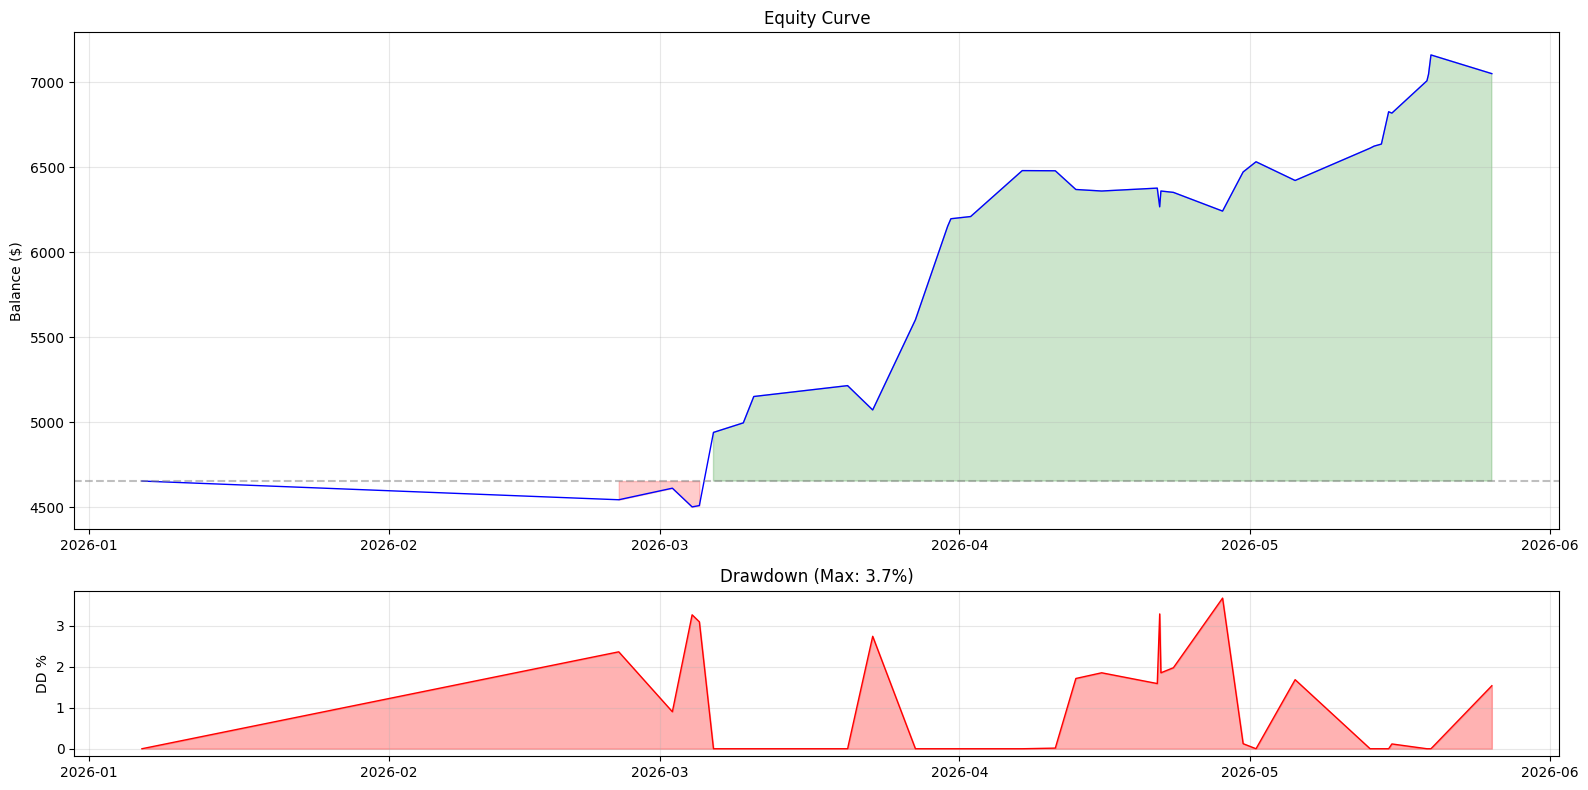


--- Recent Trades ---


,entry_time,dir,entry,exit,pnl,result,sl_pips,lot
15,2026-04-10 20:45:00,buy,1.17229,1.17238,-1.0,win,10,1.0
16,2026-04-10 23:45:00,buy,1.17255,1.17155,-110.0,loss,10,1.0
17,2026-04-15 15:45:00,buy,1.17875,1.17876,-9.0,win,13,1.0
18,2026-04-21 09:45:00,sell,1.17741,1.17714,17.0,win,10,1.0
19,2026-04-21 15:45:00,sell,1.17586,1.17686,-110.0,loss,10,1.0
20,2026-04-21 18:45:00,sell,1.17509,1.17406,93.0,win,10,1.0
21,2026-04-23 01:45:00,sell,1.17056,1.17054,-8.0,win,10,1.0
22,2026-04-28 01:45:00,buy,1.17217,1.17117,-110.0,loss,10,1.0
23,2026-04-29 19:45:00,sell,1.16841,1.16601,230.0,win,12,1.0
24,2026-05-01 14:45:00,buy,1.17508,1.17578,60.0,win,14,1.0


In [14]:
# Equity curve chart
if len(df_eq) > 0:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(df_eq['time'], df_eq['balance'], color='blue', linewidth=1)
    ax1.axhline(y=BALANCE, color='gray', linestyle='--', alpha=0.5)
    ax1.fill_between(df_eq['time'], BALANCE, df_eq['balance'], where=(df_eq['balance'] >= BALANCE), alpha=0.2, color='green')
    ax1.fill_between(df_eq['time'], BALANCE, df_eq['balance'], where=(df_eq['balance'] < BALANCE), alpha=0.2, color='red')
    ax1.set_title('Equity Curve')
    ax1.set_ylabel('Balance ($)')
    ax1.grid(alpha=0.3)

    ax2.fill_between(df_eq['time'], 0, df_eq['dd'], color='red', alpha=0.3)
    ax2.plot(df_eq['time'], df_eq['dd'], color='red', linewidth=1)
    ax2.set_title(f'Drawdown (Max: {max_dd:.1f}%)')
    ax2.set_ylabel('DD %')
    ax2.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

# Trade list
if len(df_trades) > 0:
    print('\n--- Recent Trades ---')
    cols = ['entry_time', 'dir', 'entry', 'exit', 'pnl', 'result', 'sl_pips', 'lot']
    display(df_trades[cols].tail(20).round(5) if 'lot' in df_trades.columns else df_trades.tail(20))